<a href="https://colab.research.google.com/github/UCR-JeremieRubio/IoT-Anomaly-Detection/blob/main/Karam_Kambo_%26_Jeremie_Rubio_Anomaly_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Download and extract the main dataset zip
if not os.path.exists("/content/nbaiot"):
    print("Downloading dataset...")
    os.system('wget -q -O nbaiot.zip "https://cdn.uci-ics-mlr-prod.aws.uci.edu/442/detection%2Bof%2Biot%2Bbotnet%2Battacks%2Bn%2Bbaiot.zip"')
    os.system('unzip -q -o nbaiot.zip -d /content/nbaiot > /dev/null 2>&1')

# 2. Extract the nested attack .rar files with the correct package
print("Extracting attack archives (this takes about 60 seconds)...")
os.system('apt-get -qq update > /dev/null 2>&1')
os.system('apt-get -qq install -y unrar > /dev/null 2>&1')

for rar in glob.glob("/content/nbaiot/**/*.rar", recursive=True):
    out = rar[:-4] + "_extracted"
    if not os.path.exists(out):
        os.makedirs(out, exist_ok=True)
        os.system(f'unrar x -Y -inul "{rar}" "{out}/"')

# 3. Load the CSVs
all_csvs = glob.glob("/content/nbaiot/**/*.csv", recursive=True)
benign_files = [f for f in all_csvs if "benign_traffic.csv" in f]
attack_files = [f for f in all_csvs if "benign_traffic.csv" not in f]

print(f"Found {len(benign_files)} benign files and {len(attack_files)} attack files.")

frames = []
# Load a perfectly balanced 90,000 row dataset
for b in benign_files:
    frames.append(pd.read_csv(b, nrows=5000).assign(label=0))
for a in attack_files[:10]: # Take the first 10 attack files
    frames.append(pd.read_csv(a, nrows=4500).assign(label=1))

df = pd.concat(frames, ignore_index=True)
df = df.replace([np.inf, -np.inf], np.nan).fillna(df.median(numeric_only=True))

# 4. Scale features
features = df.columns.drop("label")
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

print(f"Dataset ready. Shape: {df.shape}")
print(df['label'].value_counts())

Extracting attack archives (this takes about 60 seconds)...
Found 9 benign files and 81 attack files.


/tmp/ipykernel_18345/2437350406.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)


Dataset ready. Shape: (85500, 116)
label
0    45000
1    40500
Name: count, dtype: int64


In [2]:
summary = df.drop(columns="label").agg(["mean", "min", "max", "std"]).T
summary.columns = ["average", "min", "max", "std"]
summary.head(10).round(3)

,average,min,max,std
MI_dir_L5_weight,0.0,-0.536,3.137,1.0
MI_dir_L5_mean,0.0,-0.397,8.277,1.0
MI_dir_L5_variance,-0.0,-0.147,21.897,1.0
MI_dir_L3_weight,0.0,-0.526,2.875,1.0
MI_dir_L3_mean,-0.0,-0.402,8.340,1.0
MI_dir_L3_variance,0.0,-0.155,20.302,1.0
MI_dir_L1_weight,0.0,-0.504,2.668,1.0
MI_dir_L1_mean,-0.0,-0.417,8.436,1.0
MI_dir_L1_variance,0.0,-0.185,19.705,1.0
MI_dir_L0.1_weight,0.0,-0.508,3.541,1.0


In [3]:
import numpy as np

nulls = df.isnull().sum()
print("Total missing values:", nulls.sum())
print(nulls[nulls > 0])
print("Infinite values:", np.isinf(df.select_dtypes("number")).sum().sum())

Total missing values: 0
Series([], dtype: int64)
Infinite values: 0


In [4]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

print("Missing after cleaning:", df.isnull().sum().sum())
print("Shape:", df.shape)

Missing after cleaning: 0
Shape: (85500, 116)


In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

cat_cols = df.select_dtypes(include="object").columns
print("Categorical columns:", list(cat_cols))
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

Categorical columns: []


In [6]:
feature_cols = df.columns.drop("label")

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Mean after scaling:", round(df[feature_cols].values.mean(), 6))
print("Std after scaling: ", round(df[feature_cols].values.std(), 6))
df.head()

Mean after scaling: -0.0
Std after scaling:  1.0


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_covariance,HpHp_L0.1_pcc,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,HpHp_L0.01_covariance,HpHp_L0.01_pcc,label
0,-0.536119,-0.397202,-0.147187,-0.526246,-0.401785,-0.155383,-0.504238,-0.416536,-0.185015,-0.507974,...,-0.056742,-0.001936,-0.186103,-0.403980,-0.332061,-0.504454,-0.215338,-0.032057,0.011986,0
1,-0.536119,-0.334921,-0.147187,-0.526246,-0.338925,-0.155383,-0.504238,-0.352109,-0.185015,-0.507974,...,-0.056742,-0.001936,-0.186103,-0.339845,-0.332061,-0.451250,-0.215338,-0.032057,0.011986,0
2,-0.536119,-0.210361,-0.147186,-0.526238,-0.213317,-0.155367,-0.503917,-0.234559,-0.183629,-0.507323,...,-0.056742,-0.001936,-0.186103,-0.211574,-0.332061,-0.344840,-0.215338,-0.032057,0.011986,0
3,-0.536119,1.234553,-0.147187,-0.526246,1.245144,-0.155383,-0.504238,1.271454,-0.185015,-0.507974,...,-0.056742,-0.001936,-0.014206,1.648919,1.270129,1.198561,-0.027044,-0.032057,0.011986,0
4,-0.523749,1.276426,-0.145596,-0.517916,1.285597,-0.153795,-0.501061,1.311047,-0.183458,-0.507155,...,-0.056742,-0.001936,0.002616,1.624608,1.218543,1.178393,-0.038974,-0.032057,0.011986,0


Correlation matrix shape: (116, 116)


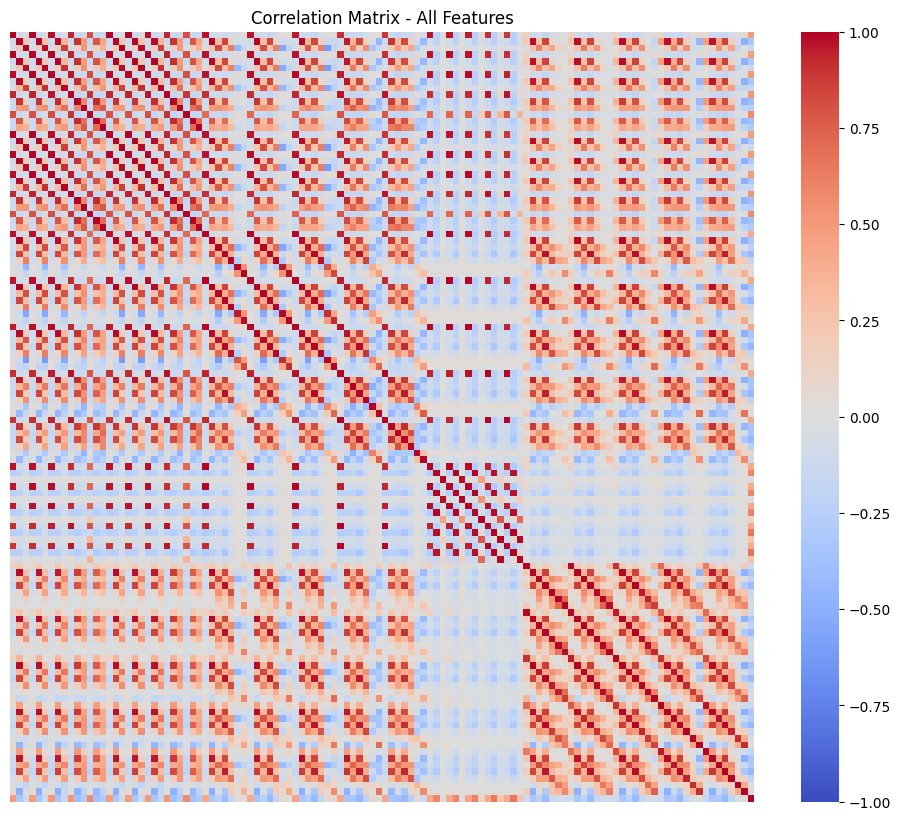

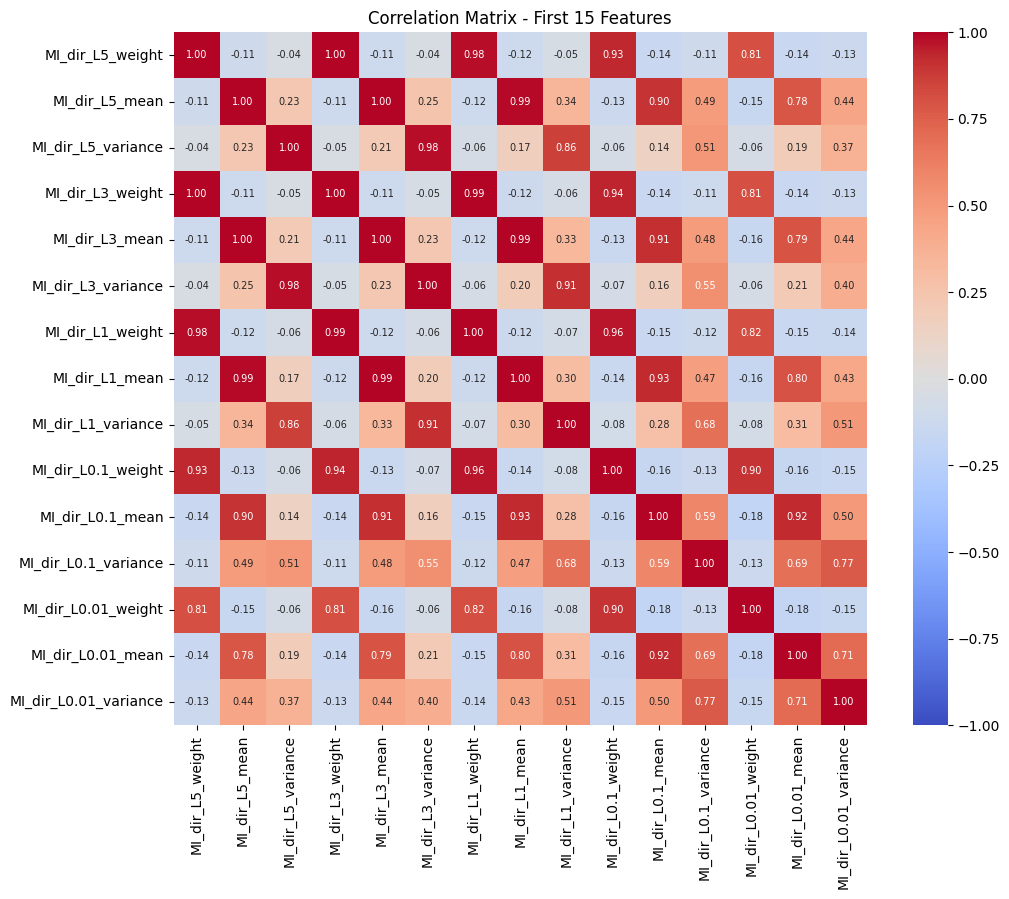


Strongest 10 features:
HH_jit_L0.01_mean      0.665
HH_jit_L0.1_mean       0.655
HH_jit_L1_mean         0.607
HH_jit_L3_mean         0.596
HH_jit_L5_mean         0.596
MI_dir_L0.01_weight    0.577
H_L0.01_weight         0.577
MI_dir_L0.1_weight     0.517
H_L0.1_weight          0.517
MI_dir_L1_weight       0.496
Name: label, dtype: float64

Weakest 10 features:
HpHp_L0.1_covariance     0.053
HpHp_L0.01_covariance    0.029
HH_jit_L5_variance       0.027
HH_jit_L3_variance       0.024
HpHp_L0.01_pcc           0.012
HH_L0.1_pcc              0.011
HH_L1_pcc                0.009
HH_L3_pcc                0.007
HH_L5_pcc                0.007
HpHp_L0.1_pcc            0.002
Name: label, dtype: float64


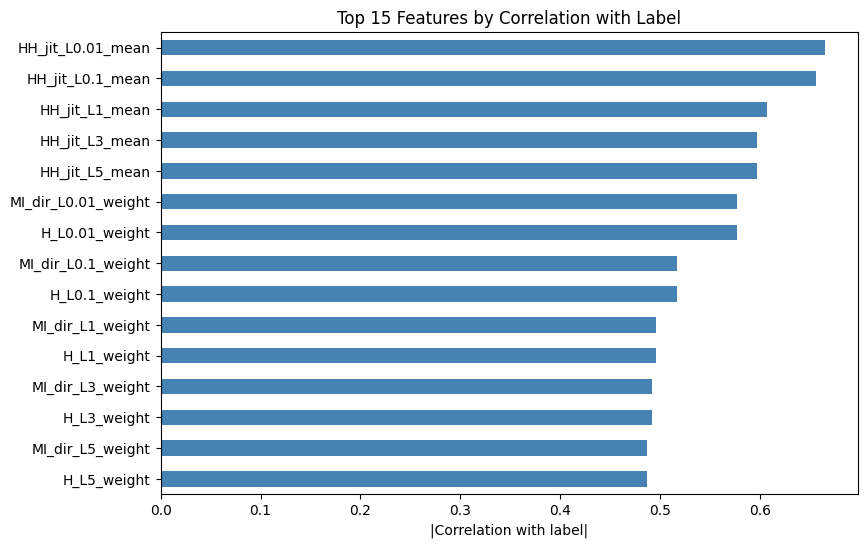


Dropped 21 features with |correlation| < 0.1
Shape: (85500, 116) -> (85500, 95)


,MI_dir_L5_weight,MI_dir_L5_mean,MI_dir_L5_variance,MI_dir_L3_weight,MI_dir_L3_mean,MI_dir_L3_variance,MI_dir_L1_weight,MI_dir_L1_mean,MI_dir_L1_variance,MI_dir_L0.1_weight,...,HpHp_L0.1_mean,HpHp_L0.1_std,HpHp_L0.1_magnitude,HpHp_L0.1_radius,HpHp_L0.01_weight,HpHp_L0.01_mean,HpHp_L0.01_std,HpHp_L0.01_magnitude,HpHp_L0.01_radius,label
0,-0.536119,-0.397202,-0.147187,-0.526246,-0.401785,-0.155383,-0.504238,-0.416536,-0.185015,-0.507974,...,-0.409285,-0.290909,-0.500047,-0.185000,-0.186103,-0.403980,-0.332061,-0.504454,-0.215338,0
1,-0.536119,-0.334921,-0.147187,-0.526246,-0.338925,-0.155383,-0.504238,-0.352109,-0.185015,-0.507974,...,-0.346751,-0.290909,-0.448477,-0.185000,-0.186103,-0.339845,-0.332061,-0.451250,-0.215338,0
2,-0.536119,-0.210361,-0.147186,-0.526238,-0.213317,-0.155367,-0.503917,-0.234559,-0.183629,-0.507323,...,-0.221682,-0.290909,-0.345336,-0.185000,-0.186103,-0.211574,-0.332061,-0.344840,-0.215338,0
3,-0.536119,1.234553,-0.147187,-0.526246,1.245144,-0.155383,-0.504238,1.271454,-0.185015,-0.507974,...,1.595322,1.454861,1.153097,0.040677,-0.014206,1.648919,1.270129,1.198561,-0.027044,0
4,-0.523749,1.276426,-0.145596,-0.517916,1.285597,-0.153795,-0.501061,1.311047,-0.183458,-0.507155,...,1.535645,1.301873,1.103883,0.002856,0.002616,1.624608,1.218543,1.178393,-0.038974,0


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# numeric features
corr = df.corr()
print("Correlation matrix shape:", corr.shape)

# heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)
plt.title("Correlation Matrix - All Features")
plt.show()

#  zoomed view
plt.figure(figsize=(12, 9))
sns.heatmap(corr.iloc[:15, :15], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, square=True)
plt.title("Correlation Matrix - First 15 Features")
plt.show()

#  Rank label
target_corr = corr["label"].drop("label").abs().sort_values(ascending=False)
print("\nStrongest 10 features:")
print(target_corr.head(10).round(3))
print("\nWeakest 10 features:")
print(target_corr.tail(10).round(3))

plt.figure(figsize=(9, 6))
target_corr.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("|Correlation with label|")
plt.title("Top 15 Features by Correlation with Label")
plt.show()

#Remove
THRESHOLD = 0.1
weak = target_corr[target_corr < THRESHOLD].index
df_selected = df.drop(columns=weak)

print("\nDropped", len(weak), "features with |correlation| <", THRESHOLD)
print("Shape:", df.shape, "->", df_selected.shape)
df_selected.head()

Extracting Frequency-Domain Features...


/tmp/ipykernel_18345/1717821326.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "td_kurtosis": kurtosis(sig),


Generating Plots...


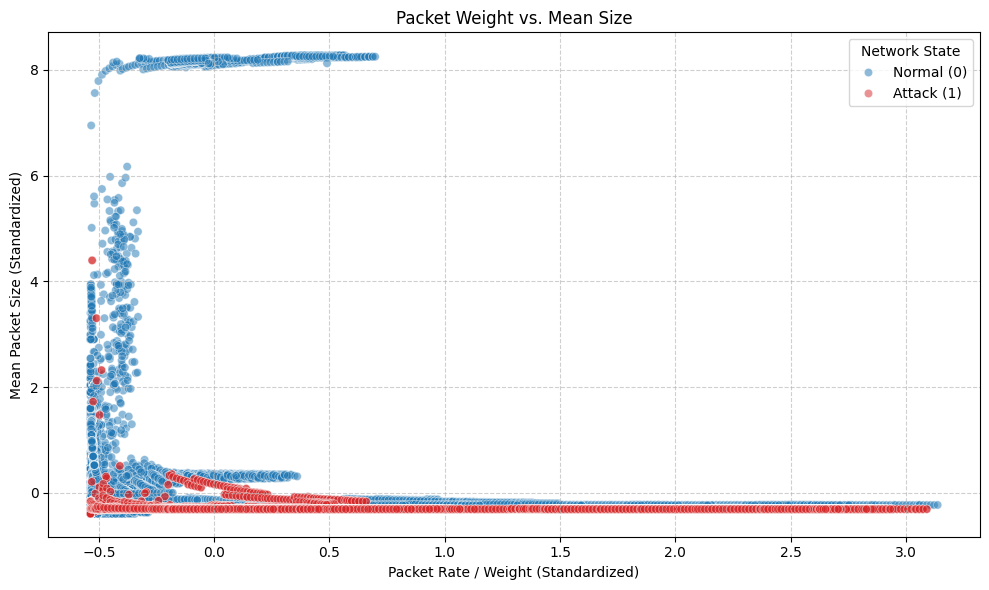

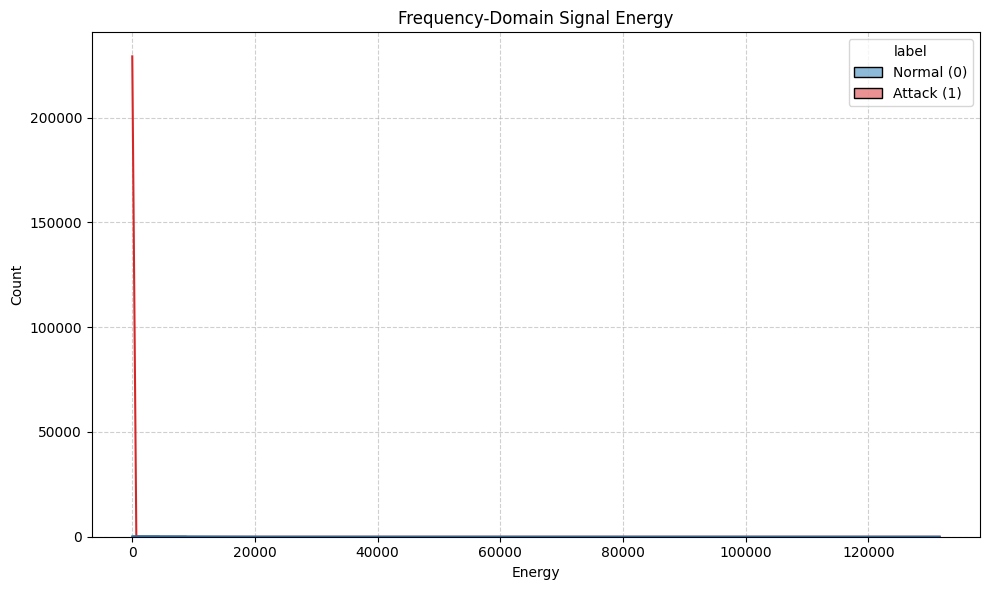

Training K-Means++ Model...
Accuracy: 0.77063
Precision: 0.84463
Recall: 0.75811
F1-score: 0.75144


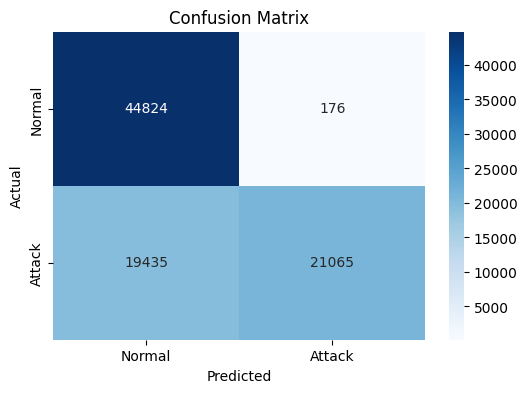

Silhouette Score: 0.67064


In [8]:
from scipy.fft import rfft
from scipy.stats import kurtosis
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# SIGNAL PROCESSING

print("Extracting Frequency-Domain Features...")
WINDOW = 128
BASE = "MI_dir_L1_mean"
rows = []
for lbl, group in df_selected.groupby("label"):
    sig_all = group[BASE].values
    for i in range(0, len(sig_all) - WINDOW + 1, WINDOW):
        sig = sig_all[i:i + WINDOW]
        spectrum = np.abs(rfft(sig - sig.mean()))
        rows.append({
            "td_mean": sig.mean(),
            "td_std": sig.std(),
            "td_range": np.ptp(sig),
            "td_kurtosis": kurtosis(sig),
            "fd_peak_freq": np.argmax(spectrum),
            "fd_peak_mag": spectrum.max(),
            "fd_energy": (spectrum ** 2).sum(),
            "label": lbl
        })
signal_df = pd.DataFrame(rows)


print("Generating Plots...")
plt.figure(figsize=(10, 6))

plot_labels = df_selected['label'].map({0: 'Normal (0)', 1: 'Attack (1)'})
sns.scatterplot(
    data=df_selected,
    x='MI_dir_L5_weight',
    y='MI_dir_L5_mean',
    hue=plot_labels,
    palette=['#1f77b4', '#d62728'],
    alpha=0.5
)
plt.title('Packet Weight vs. Mean Size')
plt.xlabel('Packet Rate / Weight (Standardized)')
plt.ylabel('Mean Packet Size (Standardized)')
plt.legend(title='Network State')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plot_labels_sig = signal_df['label'].map({0: 'Normal (0)', 1: 'Attack (1)'})
sns.histplot(
    data=signal_df,
    x='fd_energy',
    hue=plot_labels_sig,
    palette=['#1f77b4', '#d62728'],
    bins=30,
    kde=True
)
plt.title('Frequency-Domain Signal Energy')
plt.xlabel('Energy')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


print("Training K-Means++ Model...")

top_features = target_corr.head(10).index
X = df_selected[top_features]

kmeans_plus = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
kmeans_plus.fit(X)


y_true = df_selected['label']
y_pred = kmeans_plus.labels_


if accuracy_score(y_true, y_pred) < 0.5:
    y_pred = np.where(y_pred == 0, 1, 0)

print("Accuracy:", round(accuracy_score(y_true, y_pred), 5))
print("Precision:", round(precision_score(y_true, y_pred, average='macro'), 5))
print("Recall:", round(recall_score(y_true, y_pred, average='macro'), 5))
print("F1-score:", round(f1_score(y_true, y_pred, average='macro'), 5))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

sil_score = silhouette_score(X, y_pred, sample_size=10000, random_state=42)
print("Silhouette Score:", round(sil_score, 5))

In [9]:
import numpy as np, pandas as pd
from scipy.fft import rfft
from scipy.stats import kurtosis

WINDOW = 128
BASE = "MI_dir_L1_mean"   # column treated as the signal

rows = []
for lbl, group in df.groupby("label"):
    sig_all = group[BASE].values
    for i in range(0, len(sig_all) - WINDOW + 1, WINDOW):
        sig = sig_all[i:i + WINDOW]
        spectrum = np.abs(rfft(sig - sig.mean()))   # remove DC before FFT

        rows.append({
            # Time domain
            "td_mean": sig.mean(),
            "td_std": sig.std(),
            "td_range": np.ptp(sig),
            "td_kurtosis": kurtosis(sig),
            # Frequency domain
            "fd_peak_freq": np.argmax(spectrum),
            "fd_peak_mag": spectrum.max(),
            "fd_energy": (spectrum ** 2).sum(),
            "label": lbl
        })

signal_df = pd.DataFrame(rows)
print("Shape:", signal_df.shape)
print("Class counts:", signal_df["label"].value_counts().to_dict())
signal_df.head()

/tmp/ipykernel_18345/1437307227.py:20: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "td_kurtosis": kurtosis(sig),


Shape: (667, 8)
Class counts: {0: 351, 1: 316}


,td_mean,td_std,td_range,td_kurtosis,fd_peak_freq,fd_peak_mag,fd_energy,label
0,0.435625,0.609812,2.647954,2.332021,2,26.593234,3048.460761,0
1,1.102352,1.012741,2.628170,-1.759360,22,55.962819,8402.644362,0
2,1.038014,1.040434,2.539524,-1.786589,21,50.506959,8995.397649,0
3,1.099339,1.021310,2.542201,-1.751032,22,34.676912,8557.424606,0
4,1.028919,1.009514,2.553626,-1.747743,22,49.545434,8370.005629,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, silhouette_score
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

X = df.drop(columns="label").values
y = df["label"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 1. K-Means++ Clustering ---")
km = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=42)
cluster_labels = km.fit_predict(X_train)
sil_score = silhouette_score(X_train, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

print("\n--- 2. CNN Classification ---")
cnn = keras.Sequential([
    keras.layers.Input((X_train.shape[1], 1)),
    keras.layers.Conv1D(32, 5, activation="relu"),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(32, 3, activation="relu"),
    keras.layers.GlobalMaxPool1D(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])
cnn.compile(optimizer=keras.optimizers.Adam(0.01), loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(X_train, y_train, epochs=7, batch_size=256, validation_data=(X_test, y_test), verbose=1)

print("\n--- 3. K-Nearest Neighbors ---")
nn = NearestNeighbors(n_neighbors=1, metric="euclidean", algorithm="brute").fit(X_train)
idx = nn.kneighbors(X_test, return_distance=False)
knn_acc = accuracy_score(y_test, (y_train[idx][:, :1].mean(axis=1) > 0.5).astype(int))
print(f"KNN Accuracy: {knn_acc:.4f}")

--- 1. K-Means++ Clustering ---
Silhouette Score: 0.7988

--- 2. CNN Classification ---
Epoch 1/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9815 - loss: 0.0690 - val_accuracy: 0.9958 - val_loss: 0.0218
Epoch 2/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9960 - loss: 0.0170 - val_accuracy: 0.9975 - val_loss: 0.0105
Epoch 3/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.9974 - loss: 0.0100 - val_accuracy: 0.9982 - val_loss: 0.0090
Epoch 4/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9979 - loss: 0.0074 - val_accuracy: 0.9982 - val_loss: 0.0069
Epoch 5/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9982 - loss: 0.0064 - val_accuracy: 0.9982 - val_loss: 0.0086
Epoch 6/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9983 - loss: 0.0058 - val_accuracy: 0.9982 - val_loss: 0.0074
Epoch 7/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.9985 - loss: 0.0057 - val_accuracy: 0.9978 - val_loss: 0.0119

--- 3. K-N

In [11]:
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
import time

print("--- Hypothesis Testing (P-Values) ---")
g0 = df[df['label'] == 0].drop(columns="label")
g1 = df[df['label'] == 1].drop(columns="label")

# Calculate t-test p-values for all features
p_vals = np.nan_to_num(ttest_ind(g0, g1, equal_var=False)[1], nan=1.0)
p_series = pd.Series(p_vals, index=features).sort_values()

dropped_features = p_series[p_series >= 0.05].index.tolist()
print(f"Features removed due to high p-value: {dropped_features}")

print("\n--- PCA Dimensionality Reduction ---")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)

print(f"Original Feature Count: {X_train.shape[1]}")
print(f"PCA Reduced Count (95% variance): {pca.n_components_}")

# Time the CNN on PCA data to prove the speedup
start = time.time()
cnn.fit(X_train_pca, y_train, epochs=7, batch_size=256, verbose=0)
print(f"CNN Training Time on PCA Data: {time.time() - start:.2f} seconds")

--- Hypothesis Testing (P-Values) ---


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


Features removed due to high p-value: ['HpHp_L0.1_pcc']

--- PCA Dimensionality Reduction ---
Original Feature Count: 115
PCA Reduced Count (95% variance): 18
CNN Training Time on PCA Data: 15.57 seconds


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
import time

tf.random.set_seed(42)

# --- 1. Data Prep for ML ---
X = df_selected.drop(columns="label").values
y = df_selected["label"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 2. CNN Classification ---
print("\n--- CNN Classification ---")
cnn = keras.Sequential([
    keras.layers.Input((X_train.shape[1], 1)),
    keras.layers.Conv1D(32, 5, activation="relu"),
    keras.layers.MaxPool1D(2),
    keras.layers.Conv1D(32, 3, activation="relu"),
    keras.layers.GlobalMaxPool1D(),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])
cnn.compile(optimizer=keras.optimizers.Adam(0.01), loss="binary_crossentropy", metrics=["accuracy"])
cnn.fit(X_train, y_train, epochs=7, batch_size=256, validation_data=(X_test, y_test), verbose=1)

# --- 3. K-Nearest Neighbors ---
print("\n--- KNN Classification ---")
nn = NearestNeighbors(n_neighbors=1, metric="euclidean", algorithm="brute").fit(X_train)
idx = nn.kneighbors(X_test, return_distance=False)
knn_acc = accuracy_score(y_test, (y_train[idx][:, :1].mean(axis=1) > 0.5).astype(int))
print(f"KNN Accuracy: {knn_acc:.4f}")

# --- 4. LSTM Time-Series ---
print("\n--- LSTM Time-Series ---")
# Reshape for LSTM (Samples, Timesteps, Features). Using a timestep of 1 for tabular data format
X_train_seq = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_seq = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm = keras.Sequential([
    keras.layers.Input((1, X_train.shape[1])),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dense(1, activation="sigmoid")
])
lstm.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
lstm.fit(X_train_seq, y_train, epochs=15, batch_size=64, validation_data=(X_test_seq, y_test), verbose=1)

# --- 5. Hypothesis Testing ---
print("\n--- Hypothesis Testing ---")
g0 = df_selected[df_selected['label'] == 0].drop(columns="label")
g1 = df_selected[df_selected['label'] == 1].drop(columns="label")
p_vals = np.nan_to_num(ttest_ind(g0, g1, equal_var=False)[1], nan=1.0)
p_series = pd.Series(p_vals, index=df_selected.columns.drop("label")).sort_values()
dropped = p_series[p_series >= 0.05].index.tolist()
print(f"Features removed (p >= 0.05): {dropped}")

# --- 6. PCA & Training Speed Optimization ---
print("\n--- PCA Dimensionality Reduction ---")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
print(f"Original Feature Count: {X_train.shape[1]} | PCA Reduced Count: {pca.n_components_}")

start = time.time()
cnn.fit(X_train_pca, y_train, epochs=7, batch_size=256, verbose=0)
print(f"CNN Training Time on PCA Data: {time.time() - start:.2f} seconds")


--- CNN Classification ---
Epoch 1/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.9842 - loss: 0.0608 - val_accuracy: 0.9958 - val_loss: 0.0264
Epoch 2/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9967 - loss: 0.0139 - val_accuracy: 0.9974 - val_loss: 0.0081
Epoch 3/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9978 - loss: 0.0095 - val_accuracy: 0.9979 - val_loss: 0.0161
Epoch 4/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9981 - loss: 0.0073 - val_accuracy: 0.9980 - val_loss: 0.0129
Epoch 5/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9982 - val_loss: 0.0069
Epoch 6/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.9984 - val_loss: 0.0049
Epoch 7/7
268/268 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9985 - loss: 0.0056 - val_accuracy: 0.9984 - val_loss: 0.0052

--- KNN Classification ---
KNN Accuracy: 0.9997

--- LSTM Time-Series ---